<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [1]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

sdgplt.FIGSIZE = 10

### Model Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [2]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
    cov_simulation,
)


class HDLogisticMixedEffectsModel(AbstractMixedEffectsModel, AbstractHDModel):
    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["ksi"],
            **kwargs,
        )
        AbstractHDModel.__init__(self, P=P)

        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"HDLogisticMEM_N{self.N}_J{self.J}_P{self.P}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu=pc.RealPositive(scale=2000),
            ),
            psi1=pc.RealPositive(scale=100),
            psi2=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixSymPosDef(dim=1, scale=(100)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        ksi: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        psi1 = supremum
        ksi = midpoint
        psi2 = growth rate
        """
        phi = cov @ params.beta + ksi

        out = params.psi1 / (1 + jnp.exp(-(times - phi[:, None]) / params.psi2))
        assert out.shape == times.shape
        return out

    # ============================================================== #
    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
            prngkey_cov,
        ) = jrd.split(prngkey, num=3)

        # === nlmem_simulation() === #
        time = 150 + jnp.arange(0, self.J - 1) * (3000 - 150) / (self.J - 1)
        time = jnp.repeat(time[None, :], self.N, axis=0)

        cov = cov_simulation(prngkey_cov, cov_min=-1, cov_max=1, shape=(self.N, self.P))

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov=cov
        )

        return {"mem_obs_time": time, "cov": cov} | obs, sim

### Data Generation
Then we can generate a data set with $N=1000$ individuals and $J=20$ observation time per individuals

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


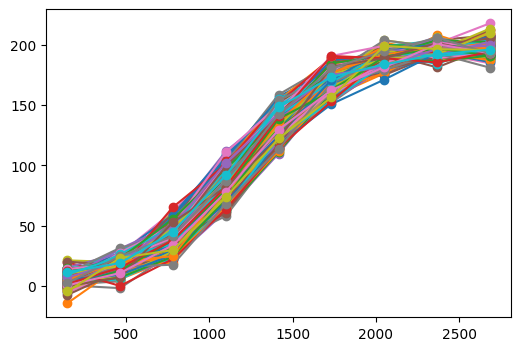

In [3]:
myModel = HDLogisticMixedEffectsModel(N=200, J=10, P=5)

p_star = myModel.new_params(
    mean_latent={"mu": 1200},
    psi1=200,
    psi2=300,
    cov_latent=jnp.diag(jnp.array([200])),
    var_residual=30,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)

myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0))

fig = sdgplt.figure(4, 6)
ax = fig.add_subplot(1, 1, 1)
_ = ax.plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

# Estimation example

Let's do an estimation of the parameter with the SGD-FIM algorithm

first we need to intiate the algorithm with accurate step size.

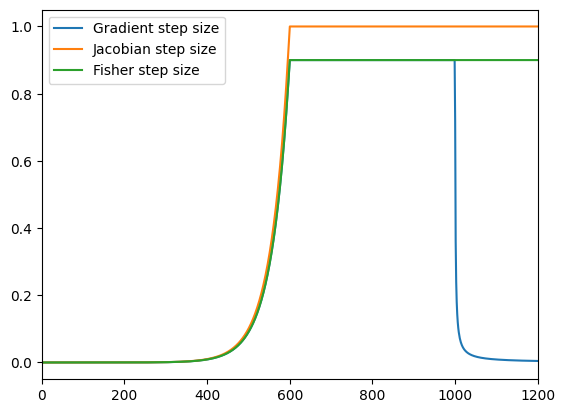

In [4]:
from sdg4varselect.outputs import GDResults, MultiRunRes
from sdg4varselect.algo import SPGD_FIM, get_GDFIM_settings
from sdg4varselect.learning_rate import create_multi_step_size

algo_settings = get_GDFIM_settings(preheating=600, heating=1000, learning_rate=1e-6)
step_sizes = create_multi_step_size(list(algo_settings))
labels = ["Gradient step size", "Jacobian step size", "Fisher step size"]
[lr.plot(label=labels[i]) for i, lr in enumerate(step_sizes)]
sdgplt.plt.legend()
_ = sdgplt.plt.xlim(0, 1200)

We define a function that make one estimation run. we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [5]:
from datetime import datetime


def one_estim(prngkey, model, data, lbd=None, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SPGD_FIM(prngkey_estim, 10000, algo_settings, lbd=lbd, alpha=1.0)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"ksi": 20})

    algo.latent_variables["ksi"].adaptative_sd = True
    # ==================== END configuration ==================== #

    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=save_all)

    return res

Now we perform severals estimations : 

In [6]:
chrono_start = datetime.now()

multi_estim = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(2)]
)
# MultiRunRes()
print(f"\ntotal = {datetime.now() - chrono_start} ")


total = 0:00:13.267295 


We can obtain the calculation time

In [7]:
print(f"\nComputation time = {multi_estim.chrono}")


Computation time = 0:00:12.718222


And plot the results

In [8]:
from sdg4varselect.outputs import get_all_theta

get_all_theta(multi_estim).shape

(10, 1038, 2)

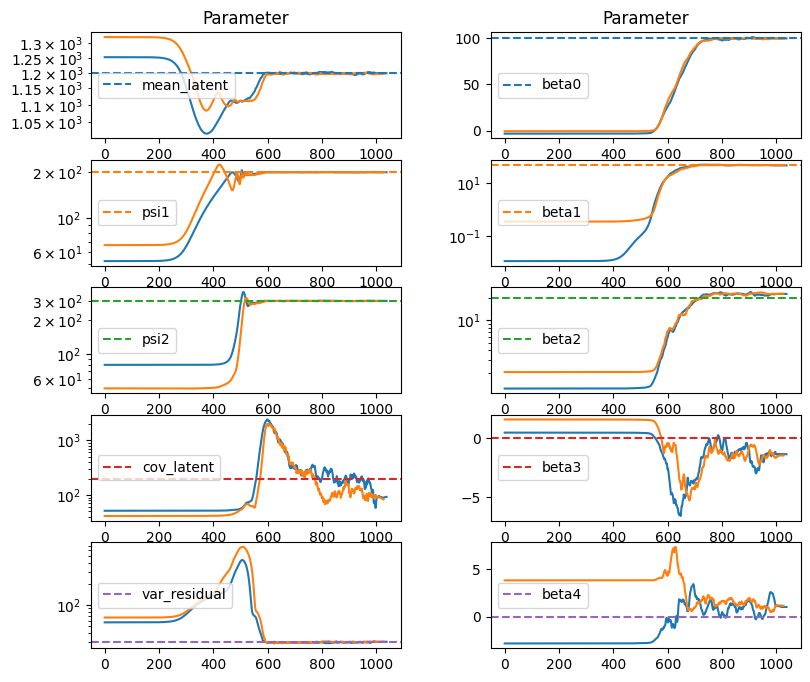

In [9]:
# === PLOT === #
sdgplt.FIGSIZE = 8

fig = sdgplt.figure()
subfigs = fig.subfigures(1, 2, wspace=0.07)

f = sdgplt.plot_theta(
    multi_estim,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    log_scale=True,
    fig=subfigs[0],
)

_ = sdgplt.plot_theta_hd(
    multi_estim,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    fig=subfigs[1],
)

In [10]:
import pandas as pd

rmse = jnp.sqrt(
    ((jnp.array(multi_estim.last_theta) - myModel.hstack_params(p_star)) ** 2).mean(
        axis=0
    )
)
pd.DataFrame(
    jnp.array(
        [
            myModel.hstack_params(p_star),
            jnp.array(multi_estim.last_theta).mean(
                axis=0,
            ),
            jnp.array(multi_estim.last_theta).var(axis=0),
            rmse,
            rmse / jnp.abs(myModel.hstack_params(p_star)),
        ]
    ).T,
    columns=["real value", "estimate", "variance", "rmse", "rrmse"],
    index=myModel.params_names,
).style.format(
    {
        "real value": "{:.1f}".format,
        "estimate": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,real value,estimate,variance,rmse,rrmse
mean_latent,1200.0,1197.41,0.703,2.7244,0.2%
psi1,200.0,199.60,0.006,0.4048,0.2%
psi2,300.0,298.13,0.054,1.8833,0.6%
cov_latent,200.0,87.67,22.227,112.4309,56.2%
var_residual,30.0,30.05,0.000,0.0570,0.2%
beta0,100.0,99.52,0.003,0.4867,0.5%
beta1,50.0,47.10,0.323,2.9519,5.9%
beta2,20.0,22.57,0.016,2.5777,12.9%
beta3,0.0,-1.42,0.003,1.4226,inf%
beta4,0.0,1.10,0.004,1.1013,inf%


In [11]:
multi_estim[0].likelihood

Array(-5639.23480519, dtype=float64)

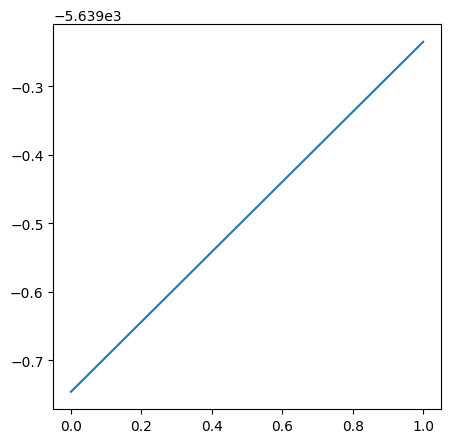

In [12]:
multi_estim.sort()

ax = sdgplt.get_ax(5, 5)
ax.plot(multi_estim.likelihood)

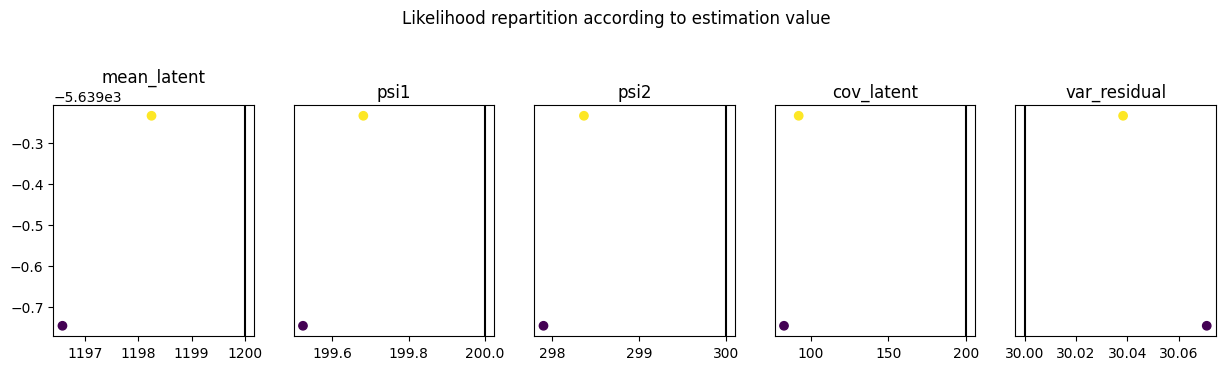

In [13]:
remove = 0

fig = sdgplt.scatter_estimation(
    multi_estim.last_theta[remove:, : myModel.DIM_LD].T,
    multi_estim.likelihood[remove:],
    vline=myModel.hstack_params(p_star)[: myModel.DIM_LD],
    labels=myModel.params_names[: myModel.DIM_LD],
    nrows=1,
    ncols=5,
    fig=sdgplt.figure(height=3, width=15),
)

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.2)

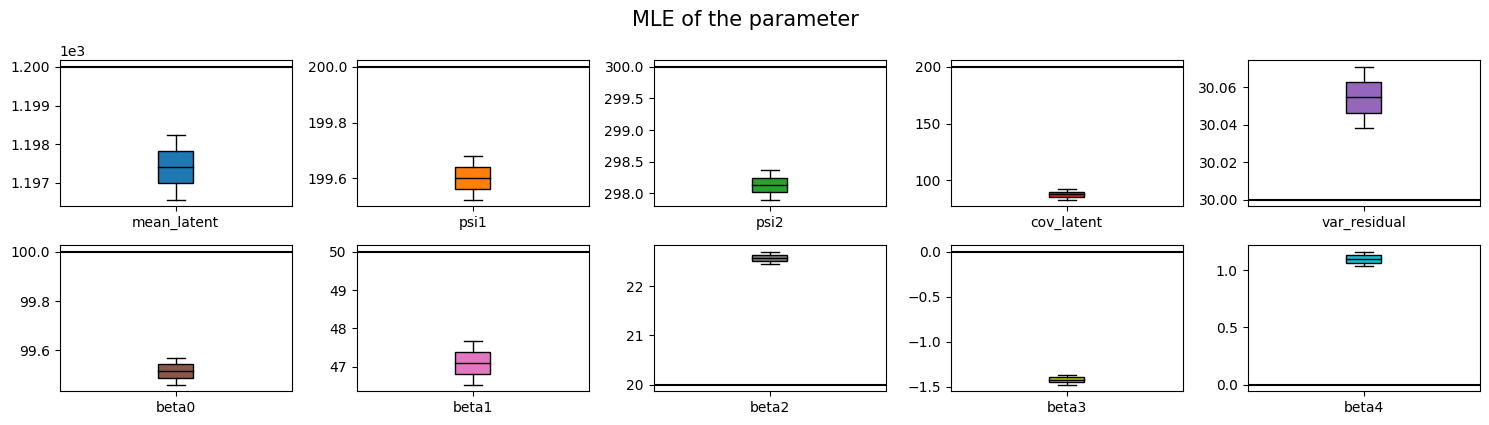

In [14]:
fig = sdgplt.boxplot_estimation(
    multi_estim.last_theta.T,
    hline=myModel.hstack_params(p_star),
    labels=myModel.params_names,
    nrows=2,
    ncols=5,
    fig=sdgplt.figure(height=4, width=15),
)
fig.tight_layout()
_ = fig.suptitle("MLE of the parameter", fontsize=15, y=1.05)

High Dimension

In [15]:
from sdg4varselect import regularization_path, lasso_into_estim
from sdg4varselect.outputs import RegularizationPathRes, MultiRunRes


def estim_with_flag(model, **kwargs) -> tuple[MultiRunRes, bool]:
    """must return the estimation results and
    a flag which indicates if the regularization path is finished"""
    res_estim = lasso_into_estim(one_estim, model=model, **kwargs)
    dim_ld = model.DIM_LD
    flag = (res_estim[-1].last_theta[dim_ld:] != 0).sum() == 0

    return res_estim, flag


def one_result(prngkey, model, data, lbd_set, save_all=True):

    list_sdg_results, bic = regularization_path(
        estim_fct_with_flag=estim_with_flag,
        prngkey=prngkey,
        lbd_set=lbd_set,
        dim_ld=model.DIM_LD,
        N=model.N * (1 + model.J),
        verbatim=True,  # __name__ == "__main__",
        # additional parameter
        model=model,
        data=data,
        save_all=save_all,
    )

    argmin_bic = bic[-1].argmin()

    return RegularizationPathRes(
        multi_run=list_sdg_results,
        argmin_bic=argmin_bic,
        bic=bic,
        lbd_set=lbd_set,
    )

One function for multiple estimation

In [16]:
from datetime import datetime

from sdg4varselect.exceptions import sdg4vsNanError
from sdg4varselect.outputs import MultiRunRes
from sdg4varselect.miscellaneous import step_message


# ====================================================== #
def multi_run(prngkey, lbd_set, params_star, model, nrun, save_all=True):
    chrono_start = datetime.now()
    print(f'start at {chrono_start.strftime("%d/%m/%Y %H:%M:%S")}')

    prngkey_list = jrd.split(prngkey, num=nrun)

    estim_res = []
    censoring_rate = []
    end = "\r" if __name__ == "__main__" else "\n"
    for k in range(nrun):
        print("run", step_message(k, nrun), end=end)
        data, _ = model.sample(params_star, prngkey_list[k])

        try:
            estim_res.append(
                one_result(
                    prngkey_list[k],
                    model,
                    data=data,
                    lbd_set=lbd_set,
                    save_all=save_all,
                ),
            )

        except sdg4vsNanError as err:
            print(f"{err} :  estimation cancelled !")

    return MultiRunRes(estim_res)

In [35]:
myHDModel = HDLogisticMixedEffectsModel(N=200, J=10, P=50)

p_star = myHDModel.new_params(
    mean_latent={"mu": 1200},
    psi1=200,
    psi2=300,
    cov_latent=jnp.diag(jnp.array([200])),
    var_residual=30,
    beta=jnp.concatenate(
        [jnp.array([100, 50, 20]), jnp.zeros(shape=(myHDModel.P - 3,))]
    ),
)

lbd_set = 10 ** jnp.linspace(-1.5, -1, num=10)

In [36]:
# # Run thos on a cluster
res = multi_run(
    jrd.PRNGKey(10),
    lbd_set,
    p_star,
    myHDModel,
    nrun=1,
    save_all=True,
)

start at 17/04/2024 11:34:11
 0/10 [>                                                  ](end in ~ 1:23:56.083370 ) )
the model have been shrink to P = 18
(200, 18)
 1/10 [=====>                                             ](end in ~ 0:38:55.209993 )
the model have been shrink to P = 16
(200, 16)
 2/10 [==========>                                        ](end in ~ 0:23:32.021712 )
the model have been shrink to P = 12
(200, 12)
 3/10 [===============>                                   ](end in ~ 0:15:44.648922 )
the model have been shrink to P = 5
(200, 5)
 4/10 [====================>                              ](end in ~ 0:10:59.057076 )
the model have been shrink to P = 3
(200, 3)
 5/10 [=========================>                         ](end in ~ 0:07:44.512765 )
the model have been shrink to P = 2
(200, 2)
 6/10 [==============================>                    ](end in ~ 0:05:23.146536 )
the model have been shrink to P = 1
(200, 1)
 7/10 [===================================>   

In [37]:
from sdg4varselect.outputs import TestResults

if "res" in locals():
    results = TestResults(
        [locals()["res"]],
        [{"N": myHDModel.N, "J": myHDModel.J, "P": myHDModel.P}],
    )
else:
    results = TestResults(
        [TestResults.load(myHDModel, filename_add_on=f"S(1, 50)")],
        [{"N": myHDModel.N, "J": myHDModel.J, "P": myHDModel.P}],
    )


print(f"chrono = {results.chrono}")
print(f"chrono by fit= {results.chrono/results.total_number_res}")
print(f"chrono by estimation= {results.chrono/len(results[0])}")
print(results.total_number_res)
print(len(results[0]))

chrono = 0:01:40.486025
chrono by fit= 0:00:05.024301
chrono by estimation= 0:01:40.486025
20
1


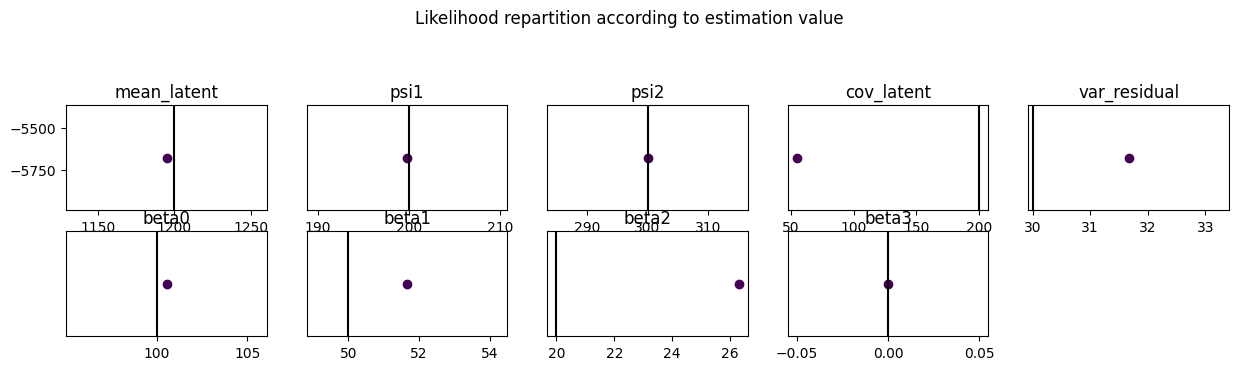

In [38]:
remove = 0
results[0].sort()

fig = sdgplt.scatter_estimation(
    results[0].last_theta[remove:, 1, : myModel.DIM_LD + 4].T,
    results[0].likelihood[remove:, 1],
    vline=myHDModel.hstack_params(p_star)[: myModel.DIM_LD + 4],
    labels=myHDModel.params_names[: myModel.DIM_LD + 4],
    nrows=2,
    ncols=5,
    fig=sdgplt.figure(height=3, width=15),
)

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.2)

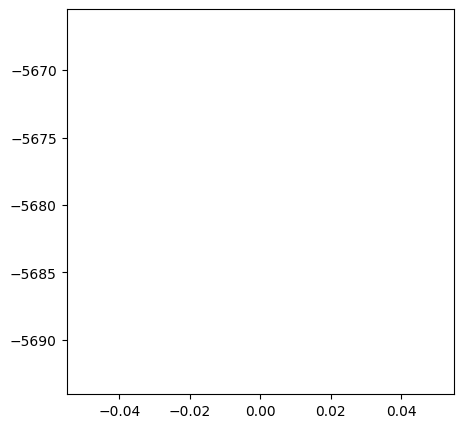

In [23]:
sdgplt.get_ax(5, 5).plot(results[0].likelihood)

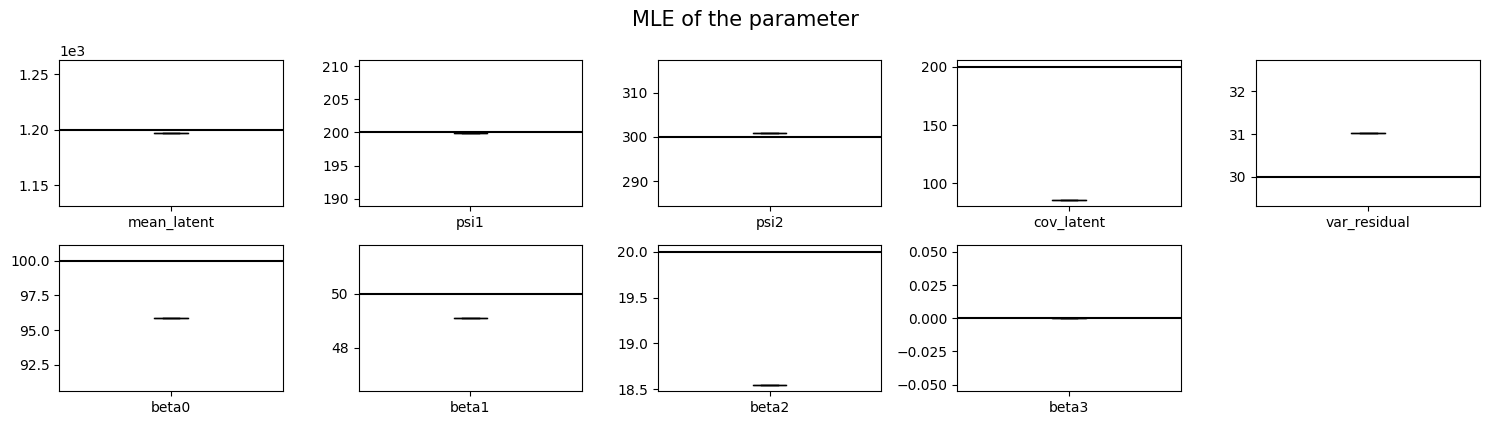

In [24]:
fig = sdgplt.boxplot_estimation(
    results[0].last_theta[remove:, 1, : myModel.DIM_LD + 4].T,
    hline=myHDModel.hstack_params(p_star)[: myModel.DIM_LD + 4],
    labels=myHDModel.params_names[: myModel.DIM_LD + 4],
    nrows=2,
    ncols=5,
    fig=sdgplt.figure(height=4, width=15),
)
fig.tight_layout()
_ = fig.suptitle("MLE of the parameter", fontsize=15, y=1.05)

In [39]:
last_theta_estim = results[0].last_theta[:, 1]

sdgplt.get_dataframe_results(
    last_theta_estim, myHDModel.hstack_params(p_star), myHDModel.params_names
).style.format(
    {
        "rmse": "{:.4f}".format,
        "value": "{:.4f}".format,
        "real value": "{:.3f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,rmse,value,variance,real value,rrmse
mean_latent,5.1987,1194.8013,0.000000,1200.000,0.4%
psi1,0.1882,199.8118,0.000000,200.000,0.1%
psi2,0.0106,300.0106,0.000000,300.000,0.0%
cov_latent,145.1960,54.8040,0.000000,200.000,72.6%
var_residual,1.6689,31.6689,0.000000,30.000,5.6%
beta0,0.5405,100.5405,0.000000,100.000,0.5%
beta1,1.6623,51.6623,0.000000,50.000,3.3%
beta2,6.2997,26.2997,0.000000,20.000,31.5%


IndexError: list index out of range

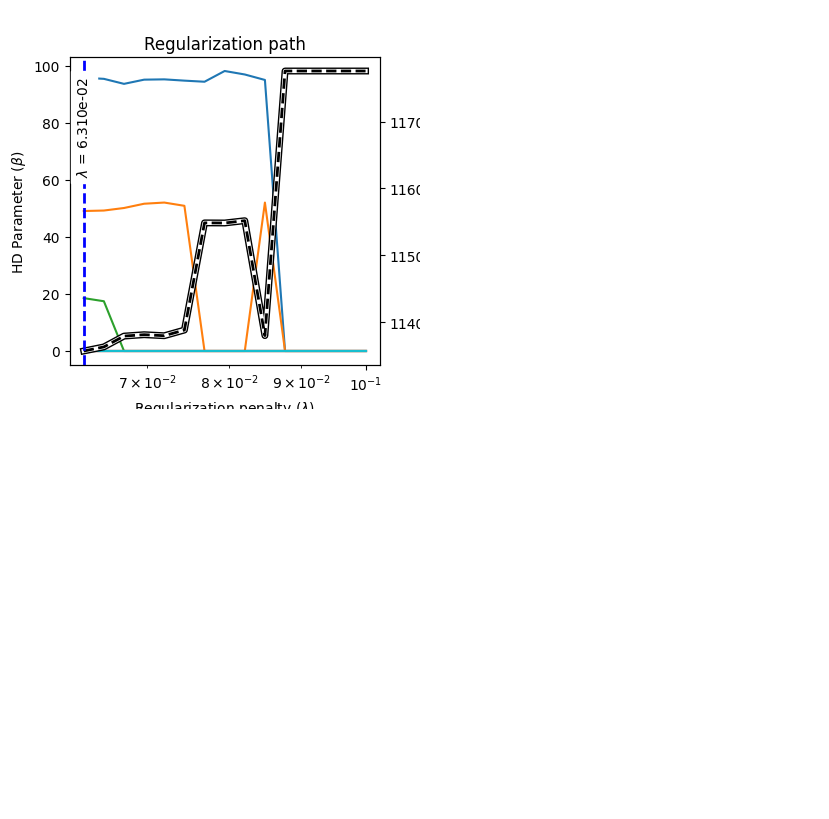

In [28]:
fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(2, 2, wspace=0.07)

for i, subfigsarr in enumerate(subfigs):
    for j, subfig in enumerate(subfigsarr):
        sdgplt.plot_reg_path(
            reg_res=results[0][i * subfigs.shape[0] + j],
            dim_ld=myHDModel.DIM_LD,
            fig=subfig,
        )

In [ ]:
lbd_set

'-1.0555555555555554 -0.9999999999999998'

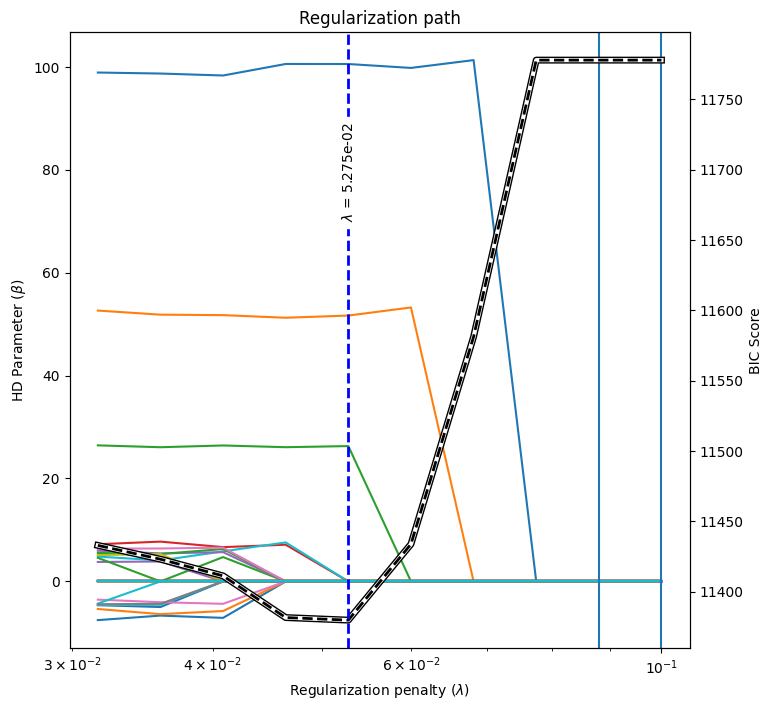

In [40]:
fig = sdgplt.plot_reg_path(
    reg_res=results[0][0],
    dim_ld=myHDModel.DIM_LD,
)
ax = fig.axes[0]
ax.axvline(x=lbd_set[8])
ax.axvline(x=lbd_set[14])
f"{jnp.log10(lbd_set[8])} {jnp.log10(lbd_set[12])}"

In [ ]:
theta = results.last_theta.T[myHDModel.DIM_LD :].T

In [ ]:
theta.shape

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

params_star_HD = myHDModel.hstack_params(p_star)[myHDModel.DIM_LD :]
import numpy as np

# theta = np.concatenate((thetax, np.zeros((1, 10, 3, 90))), axis=3)

# id = np.random.choice([i for i in range(100 - 4)], size=100 - 4, replace=False)
# theta[:, :, :, 4:] = theta[:, :, :, 4:][:, :, :, id]

# G = GridSpec(len(results), 3)
fig = sdgplt.figure()

n_method = 1

P_max = theta.shape[-1]
xticks = jnp.arange(0, P_max) + 1
dmax = 3
for i in range(len(results)):
    ax = fig.add_subplot(len(results), 1, 1 + i)  # plt.subplot(G[i, 0])
    # print(theta[i][:, n_method, :4].T)
    print(theta[i][:dmax, n_method].shape)

    sdgplt.myBoxplot(ax=ax, x=theta[i][:dmax, n_method])
    ax.plot(xticks[:dmax], params_star_HD[:dmax], "bs", label="true value")

    ax.legend()
    # ax.set_ylabel(scenarios_labels[i])
    # == == == == #
    # ax = plt.subplot(G[i, 1:], sharey=ax)
    # ax = boxplot(ax, theta[i][:, n_method, dmax:])
    # xticks_nonzero = jnp.arange(dmax, P_max, step=P_max // 10) - 3
    # ax.set_xticks(xticks_nonzero, xticks[xticks_nonzero])

# ax = plt.subplot(G[0, 0])
# ax.set_title(f"Estimation of the {dmax} non-zero components of beta", fontsize=15)
# ax = plt.subplot(G[0, 1:], sharey=ax)
# ax.set_title(f"Estimation of the remaining zero components of beta", fontsize=15)